In [1]:
# ===================== 自动安装所有依赖包=====================
import importlib
import subprocess
import sys

required_packages = ["numpy", "pandas", "matplotlib", "seaborn", "scipy"]
for pkg in required_packages:
    try:
        importlib.import_module(pkg)
    except ImportError:
        print(f"正在安装 {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

    print("✅ 所有依赖包已准备完成！")

✅ 所有依赖包已准备完成！
✅ 所有依赖包已准备完成！
✅ 所有依赖包已准备完成！
✅ 所有依赖包已准备完成！
✅ 所有依赖包已准备完成！


In [2]:
# =======================清除环境=================================
%reset -f

In [3]:
# =======================启动库=================================
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import warnings
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from pylab import *

warnings.filterwarnings('ignore')
pd.set_option('mode.chained_assignment', None)

In [4]:

# ===================== 工作目录=====================
root_dir = r'C:\Users\50847\OneDrive\桌面\work'
os.makedirs(root_dir, exist_ok=True)
os.chdir(root_dir)

# 图片保存目录（你指定的）
save_fig_dir = r'C:\Users\50847\OneDrive\桌面\work\figure'
os.makedirs(save_fig_dir, exist_ok=True)
# ==================================================================

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [5]:
# ===================== 数据读取路径=====================
df_site = pd.read_csv(r"C:\Users\50847\OneDrive\桌面\work\data\sites_meta_info.csv", index_col=0)
df_SNR = pd.read_csv(r"C:\Users\50847\OneDrive\桌面\work\data\beta_SNR_results.csv", index_col=0)


✅ 图片已保存到：
C:\Users\50847\OneDrive\桌面\work\figure\Fig4_PFT_dependence.png


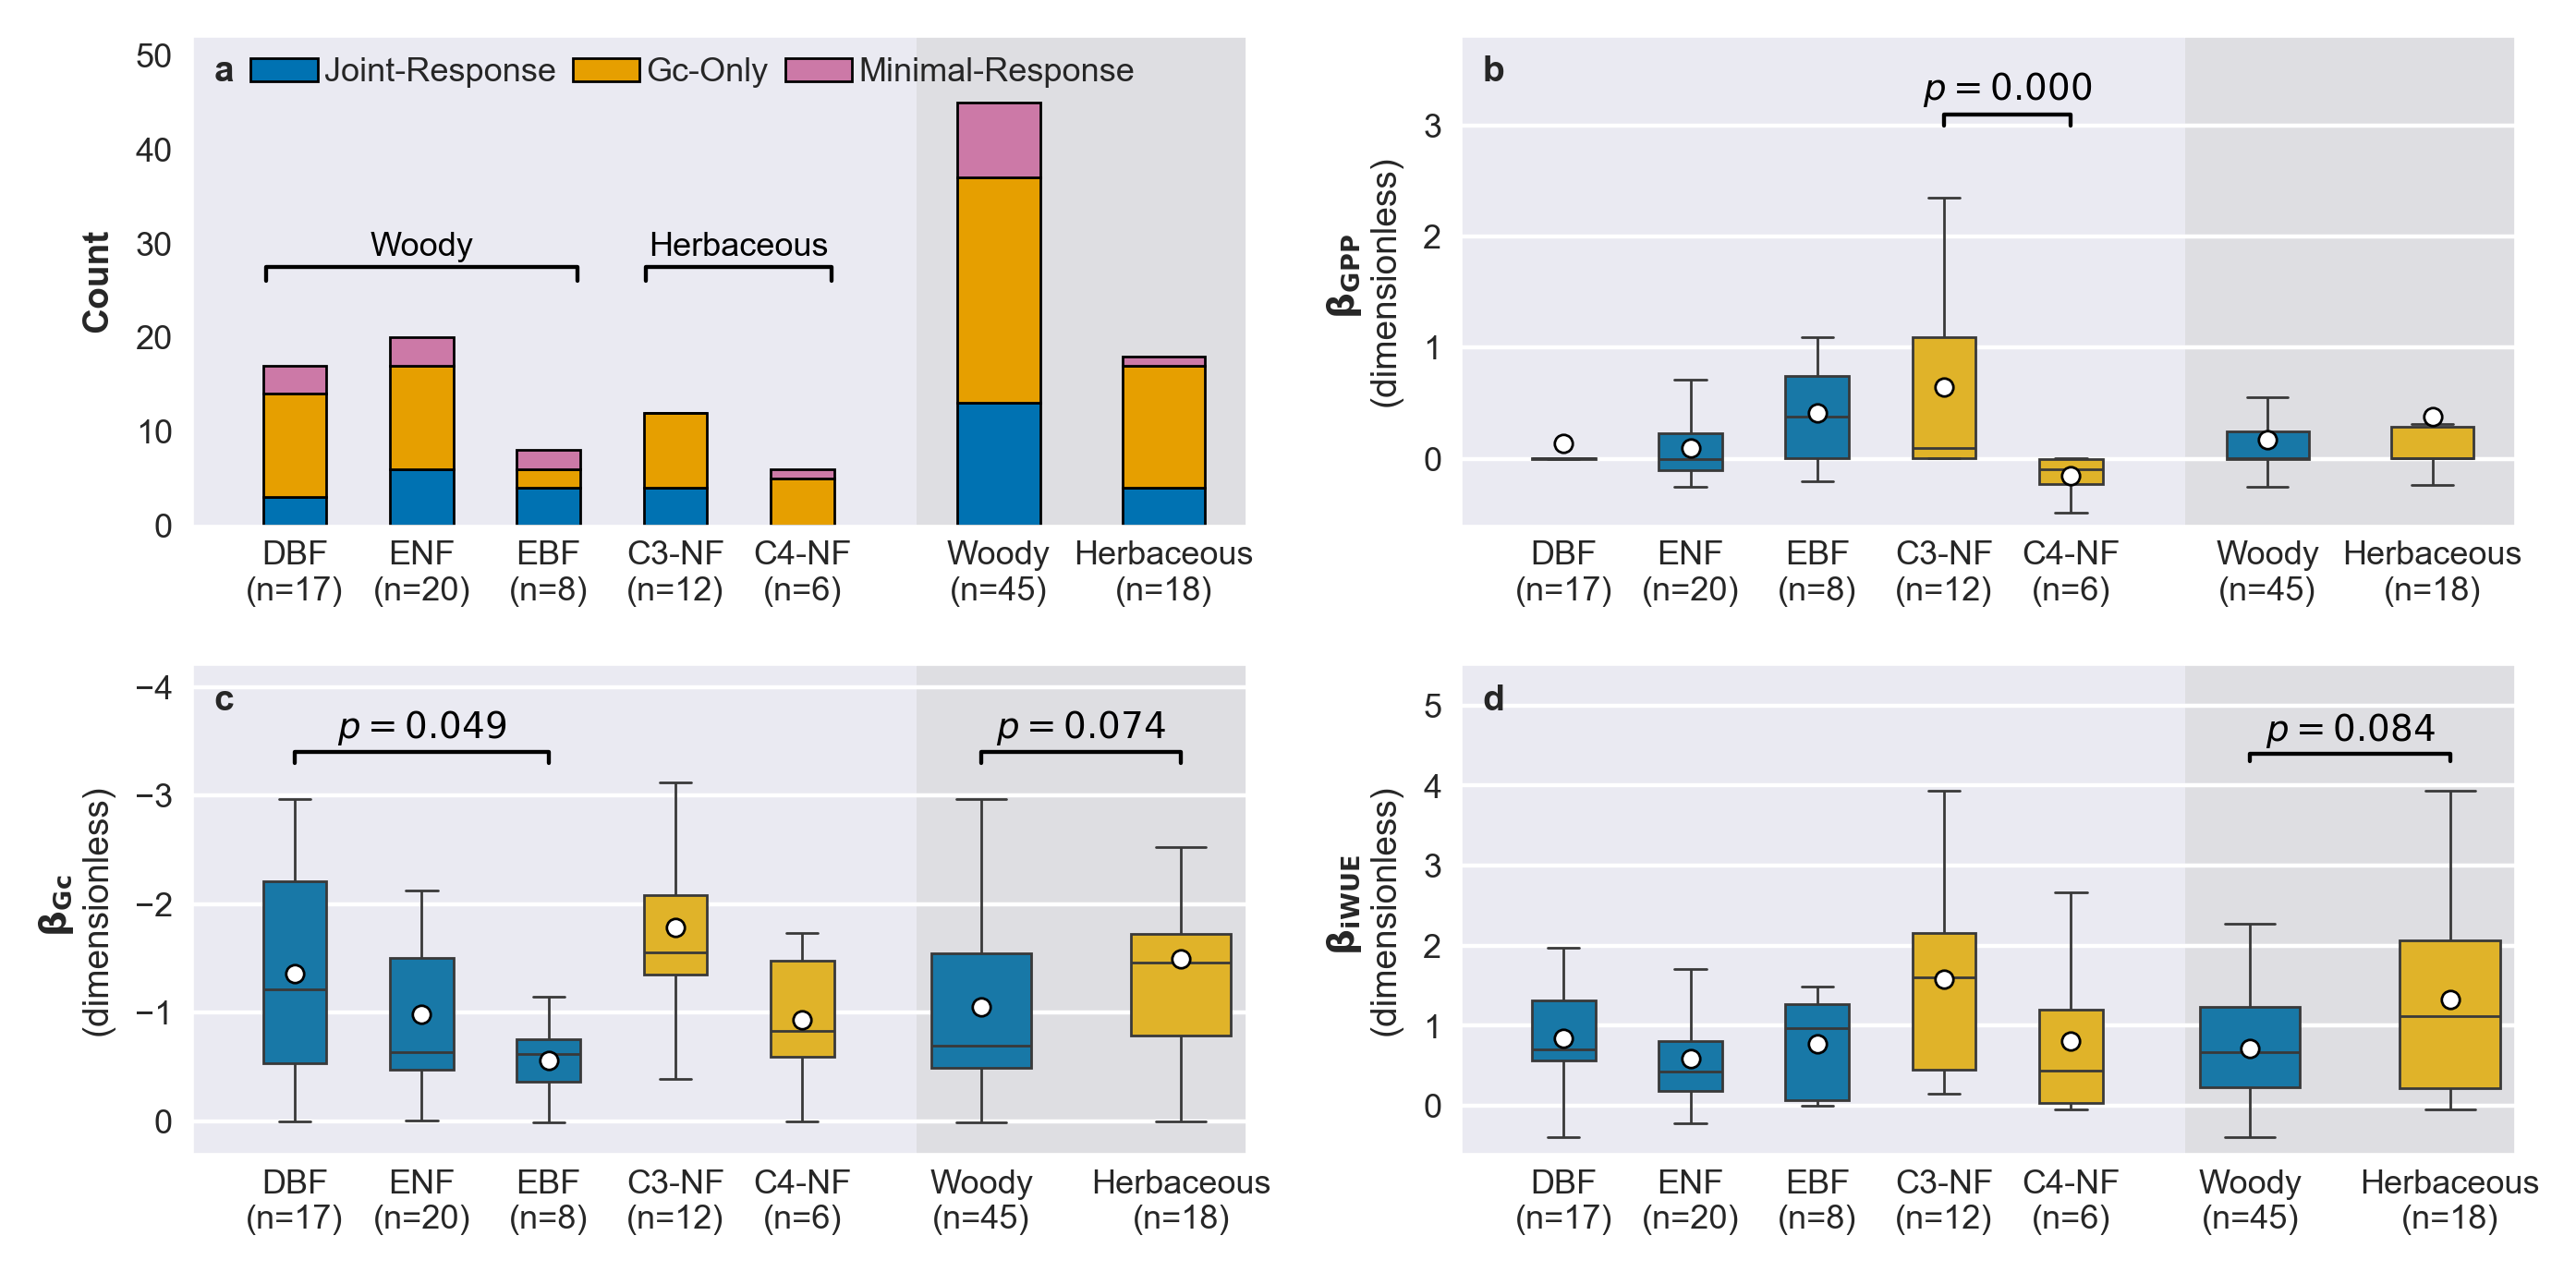

In [6]:
# ==========================绘图===============================

## Fig 4: dependence on plant functional types
def add_inset_axis(ax, x_loc, xmin, xmax, broad_group, var_y, df, order_broad):
    broad_color_dic = {'Woody': '#0080bf', 'Herbaceous': '#FFC20A'}
    ratio = (x_loc - xmin) / (xmax - xmin)
    axins = ax.inset_axes([ratio, 0, 1 - ratio, 1])
    axins.patch.set_facecolor("lightgrey")
    axins.patch.set_alpha(0.5)
    boxplot_multiple_group(broad_group, var_y, df, order_broad, broad_color_dic, axins)

    axins.tick_params(top=False, left=False, labelleft=False, labelbottom=True)
    axins.spines['left'].set_visible(False)

    axins.set_xlabel('')
    axins.set_ylabel('')

    return axins


def boxplot_multiple_group(group_col, var_y, df, order, palette, ax,
                           showfliers=False, strip=False):
    sns.boxplot(x=group_col, y=var_y, data=df, order=order, palette=palette, ax=ax,
                width=0.5, fliersize=7, showfliers=showfliers, linewidth=1, showmeans=True,
                meanprops={"marker": "o",
                           "markerfacecolor": "white",
                           "markeredgecolor": "black",
                           "markersize": "7"})
    if strip:
        sns.stripplot(x=group_col, y=var_y, data=df, color='black', order=order, ax=ax, size=8, alpha=0.2)


cluster_color_dic = {1: '#0072B2', 2: '#E69F00', 3: '#CC79A7',
                     4: '#56B4E9', 5: '#009E73', 6: '#F0E442',
                     7: '#D55E00', 9999: 'black'}
df_SNR_update = df_SNR.copy()

# classify PFTs into woody and herbaceous
woody = ['DBF', 'EBF', 'ENF']
herb = ['C3-NF', 'C4-NF']

df_SNR_update.loc[df_SNR_update.Cover_type.isin(woody), 'broad_class'] = 'Woody'
df_SNR_update.loc[df_SNR_update.Cover_type.isin(herb), 'broad_class'] = 'Herbaceous'

df_SNR_update.loc[df_SNR_update.Cover_type.isin(woody), 'broad_class_id'] = 5
df_SNR_update.loc[df_SNR_update.Cover_type.isin(herb), 'broad_class_id'] = 6
# check the distribution of different response patterns across different PFTs
col1 = 'Cover_type'
col1_broad = 'broad_class'

vars_1 = ['DBF', 'ENF', 'EBF', 'C3-NF', 'C4-NF']
vars_1_broad = ['Woody', 'Herbaceous']

col2 = 'new_ID'
vars_2 = df_SNR_update[col2].unique().tolist()
vars_2.sort()

df_stat = pd.DataFrame(index=vars_1, columns=vars_2)
df_stat_broad = pd.DataFrame(index=vars_1_broad, columns=vars_2)

for var1 in vars_1:
    df = df_SNR_update[df_SNR_update[col1] == var1]
    gb = df.groupby(col2).count().iloc[:, 0]

    for var2 in gb.index:
        df_stat.loc[var1, var2] = gb[var2]

for var1 in vars_1_broad:
    df = df_SNR_update[df_SNR_update[col1_broad] == var1]
    gb = df.groupby(col2).count().iloc[:, 0]

    for var2 in gb.index:
        df_stat_broad.loc[var1, var2] = gb[var2]

fontsize = 6.5

plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 800
plt.rcParams['font.size'] = fontsize
plt.rcParams['font.family'] = 'Arial'


def add_inset_axis_barplot(ax, x_loc, xmin, xmax, df, cluster_color_dic):
    ratio = (x_loc - xmin) / (xmax - xmin)
    axins = ax.inset_axes([ratio, 0, 1 - ratio, 1])
    axins.patch.set_facecolor("lightgrey")
    axins.patch.set_alpha(0.5)

    df.plot(kind="bar", linewidth=0.5, stacked=True, ax=axins,
            legend=False, grid=False, edgecolor='black',
            color=[cluster_color_dic[c] for c in df.columns])

    axins.tick_params(top=False, left=False, labelleft=False, labelbottom=True)
    axins.spines['left'].set_visible(False)

    axins.set_xlabel('')
    axins.set_ylabel('')

    return axins


def boxplot_multiple_group(group_col, var_y, df, order, palette, ax,
                           showfliers=False, strip=False):
    sns.boxplot(x=group_col, y=var_y, data=df, order=order, palette=palette, ax=ax,
                width=0.5, fliersize=7, showfliers=showfliers, linewidth=0.5, showmeans=True,
                meanprops={"marker": "o",
                           "markerfacecolor": "white",
                           "markeredgecolor": "black",
                           "markersize": "3.5",
                           "markeredgewidth": 0.5})
    if strip:
        sns.stripplot(x=group_col, y=var_y, data=df,
                      color='black', order=order, ax=ax, size=8, alpha=0.2)


def anno_sig_boxplot(x1, x2, y, h, ax, df, group_col, var_y, order, threshold=0.1, fontsize=fontsize + 0.5):
    col = 'k'
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=0.78, c=col)

    data1 = df.loc[df[group_col] == order[x1], var_y].dropna()
    data2 = df.loc[df[group_col] == order[x2], var_y].dropna()

    statistic, p_value = mannwhitneyu(data1, data2)

    if p_value < threshold:
        ax.text((x1 + x2) * .5, y + h * 1.5, '$p=%.3f$' % (p_value),
                ha='center', va='bottom', color=col, fontsize=fontsize)


fig_w, fig_h = 13, 6.5
width_new = 7
height_new = fig_h / fig_w * width_new

fig, axes = plt.subplots(figsize=(width_new, height_new), nrows=2, ncols=2, dpi=200)
ax1, ax2, ax3, ax4 = axes.flatten()

# common setting across subplots
xmin, xmax = -0.8, 7.5
x_loc = 4.9
palette = {'DBF': '#0080bf', 'ENF': '#0080bf', 'EBF': '#0080bf', 'C3-NF': '#FFC20A', 'C4-NF': '#FFC20A'}
order = ['DBF', 'ENF', 'EBF', 'C3-NF', 'C4-NF']
group_col = 'Cover_type'
broad_group = 'broad_class'
order_broad = ['Woody', 'Herbaceous']

# ---------- subplot 1 -----------
barplot = df_stat.plot(kind="bar", linewidth=0.5, stacked=True, ax=ax1, grid=False, edgecolor='black',
                       color=[cluster_color_dic[c] for c in df_stat.columns])
handles, labels = barplot.get_legend_handles_labels()
labels = ['Joint-Response', 'Gc-Only', 'Minimal-Response']
l = ax1.legend(handles, labels, title=None, bbox_to_anchor=(0.026, 1.02),
               loc='upper left', ncols=3, columnspacing=0.5, handletextpad=0.2,
               markerscale=0.7)

lw = 0.78

y, h = 26, 1.5
x1, x2 = -0.23, 2.23
ax1.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c='k')
ax1.text((x1 + x2) * .5, y + h + 0.5, 'Woody', ha='center', va='bottom', color='k', fontsize=fontsize)

x1, x2 = -0.23 + 3, 2.23 + 2
ax1.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c='k')
ax1.text((x1 + x2) * .5, y + h + 0.5, 'Herbaceous', ha='center', va='bottom', color='k', fontsize=fontsize)

ymin, ymax = 0, 52
axin1 = add_inset_axis_barplot(ax1, x_loc, xmin, xmax, df_stat_broad, cluster_color_dic)
axin1.set_ylim([ymin, ymax])
ax1.set_ylim([ymin, ymax])
ax1.set_xlim([xmin, xmax])
ax1.set_xlabel('')
ax1.set_ylabel('Count', fontsize=fontsize + 0.5, fontweight='bold')
ax1.tick_params(axis='x', labelrotation=0)
axin1.tick_params(axis='x', labelrotation=0)

# ------------ subfig 2 ---------------
var_y = 'GPP_beta'

boxplot_multiple_group(group_col, var_y, df_SNR_update, order, palette, ax2)

ymin, ymax = -0.6, 3.8
axin2 = add_inset_axis(ax2, x_loc, xmin, xmax, broad_group, var_y, df_SNR_update, order_broad)
axin2.set_ylim([ymin, ymax])
ax2.set_ylim([ymin, ymax])
ax2.set_xlim([xmin, xmax])
ax2.set_xlabel('')
idx = var_y.split('_')[0]
ax2.set_ylabel(fr' $\mathbf{{\beta_{{{idx}}}}}$' + '\n(dimensionless)', fontsize=fontsize + 0.5)

# statistical test
anno_sig_boxplot(3, 4, 3, 0.1, ax2, df_SNR_update, group_col, var_y, order,
                 threshold=0.1, fontsize=fontsize + 0.5)

# ------------- subfig 3 ---------------
var_y = 'Gc_beta'
boxplot_multiple_group(group_col, var_y, df_SNR_update, order, palette, ax3)

axin3 = add_inset_axis(ax3, x_loc, xmin, xmax, broad_group, var_y, df_SNR_update, order_broad)

ymin, ymax = -0.3, 4.2
axin3.set_ylim([-ymax, -ymin])
ax3.set_ylim([-ymax, -ymin])

ax3.set_xlim([xmin, xmax])
ax3.set_xlabel('')
idx = var_y.split('_')[0]
ax3.set_ylabel(fr' $\mathbf{{\beta_{{{idx}}}}}$' + '\n(dimensionless)', fontsize=fontsize + 0.5)

# statistical test
anno_sig_boxplot(0, 1, -3.3, -0.1, axin3, df_SNR_update, broad_group, var_y, order_broad, threshold=0.1)
anno_sig_boxplot(0, 2, -3.3, -0.1, ax3, df_SNR_update, group_col, var_y, order, threshold=0.1)

ax3.invert_yaxis()
axin3.invert_yaxis()

# ------------ subfig 4 ---------------
var_y = 'iWUE_beta'

boxplot_multiple_group(group_col, var_y, df_SNR_update, order, palette, ax4)

ymin, ymax = -0.6, 5.5
axin4 = add_inset_axis(ax4, x_loc, xmin, xmax, broad_group, var_y, df_SNR_update, order_broad)
axin4.set_ylim([ymin, ymax])
ax4.set_ylim([ymin, ymax])
ax4.set_xlim([xmin, xmax])
ax4.set_xlabel('')
idx = var_y.split('_')[0]

ax4.set_ylabel(fr' $\mathbf{{\beta_{{{idx}}}}}$' + '\n(dimensionless)', fontsize=fontsize + 0.5)

# statistical test
anno_sig_boxplot(0, 1, 4.3, 0.1, axin4, df_SNR_update, broad_group, var_y, order_broad, threshold=0.1)

seq = ['a', 'b', 'c', 'd']
for i, ax in enumerate([ax1, ax2, ax3, ax4, axin1, axin2, axin3, axin4]):
    ax.tick_params(width=0.3, length=2)
    ax.tick_params(axis='x', pad=1)
    ax.tick_params(axis='y', pad=2)

    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

n_DBF = df_site.groupby('update_PFT').size()['DBF']
n_ENF = df_site.groupby('update_PFT').size()['ENF']
n_EBF = df_site.groupby('update_PFT').size()['EBF']
n_C3 = df_site.groupby('update_PFT').size()['C3-NF']
n_C4 = df_site.groupby('update_PFT').size()['C4-NF']

n_woody = n_DBF + n_ENF + n_EBF
n_herb = n_C3 + n_C4

for i, ax in enumerate([ax1, ax2, ax3, ax4]):
    ax.set_xticklabels([
        f'DBF\n(n={n_DBF})',
        f'ENF\n(n={n_ENF})',
        f'EBF\n(n={n_EBF})',
        f'C3-NF\n(n={n_C3})',
        f'C4-NF\n(n={n_C4})'], fontsize=fontsize)
    ax.annotate(seq[i], xy=(4, 86.5), xycoords='axes points', fontweight='bold', fontsize=fontsize + 0.5)

for ax in [axin1, axin2, axin3, axin4]:
    ax.set_xticklabels([f'Woody\n(n={n_woody})',
                        f'Herbaceous\n(n={n_herb})'], fontsize=fontsize)

plt.tight_layout()
# ===================== 【自动保存图片】=====================
save_path = os.path.join(save_fig_dir, 'Fig4_PFT_dependence.png')
plt.savefig(save_path, dpi=800, bbox_inches='tight')
print(f"✅ 图片已保存到：\n{save_path}")
# ==========================================================

plt.show()